# Reproducing Figure 2 of Gast, Solla & Kennedy (2024, PNAS)

*"Neural heterogeneity controls computations in spiking neural networks"*
(PNAS 121(22) e2311885121, [doi:10.1073/pnas.2311885121](https://doi.org/10.1073/pnas.2311885121)).

This notebook reproduces the **twelve panels (A–L) of Figure 2** of that paper.
Figure 2 shows how **spike-threshold heterogeneity** in an inhibitory
(fast-spiking, FS) interneuron population controls whether the inhibitory
population *overwrites* or *preserves* the bifurcation structure of a
recurrent excitatory (regular-spiking, RS) population.

**Layout of the reproduced figure**

| column | panels | content |
|---|---|---|
| 1 | A, E, I | 2-D bifurcation diagrams (single population, then RS–FS with high / low FS heterogeneity) |
| 2 | B, F, J | same, for strong spike-frequency adaptation ($\kappa_{rs}=100$ pA) |
| 3 | C, D, G, H, K, L | firing-rate dynamics: sparse spiking network (black) vs. mean-field (orange) |

Two model levels are used, exactly as in the paper:

1. **Spiking network** – sparse, random Izhikevich (2003) neurons (Eqs. 1–4) with a
   Lorentzian distribution of spike thresholds.
2. **Mean-field model** – the four-dimensional firing-rate equations (Eqs. 6–9) that
   the paper derives analytically for that network (Gast, Schmidt & Knösche, 2021;
   Gast, Solla & Kennedy, 2024).

The mean-field model is **not** part of TVB's model library, so it is implemented
directly here with NumPy/SciPy; the notebook lives in the TVB demo collection as a
literature-reproduction demo (cf. `remake_figure_WilsonCowan.ipynb`).

> **Note.** This is a from-scratch, self-contained reproduction, not the authors' code.
> The authors' own scripts (PyRates / RectiPy / PyCoBi) are archived at
> Zenodo [10.5281/zenodo.10420635](https://doi.org/10.5281/zenodo.10420635).
> Regions and curves are reproduced by direct numerical analysis rather than AUTO
> continuation, so the panels are *qualitatively* faithful, not pixel-perfect.

## 1. The model

### Spiking network (Eqs. 1–4)
For neuron $i$ of a population:

$$C \dot v_i = k(v_i-v_r)(v_i-\theta_i) - u + I(t) + g\,s\,(E-v_i)$$
$$\tau_u \dot u = -u + b\!\left(\tfrac1N\textstyle\sum_j v_j\right) + \tau_u\,\kappa\, r$$
$$\tau_s \dot s = -s + \tau_s J\,r, \qquad r(t)=\tfrac1N\sum_j\sum_k \delta(t-t_{jk})$$

The **spike thresholds** $\theta_i$ are drawn from a truncated Lorentzian of
half-width-at-half-maximum $\Delta_v$ centred at $\bar v_\theta$; $\Delta_v$ is the
**heterogeneity** parameter. RS neurons have spike-frequency adaptation $\kappa$.

### Mean-field model (Eqs. 6–9)
With $\sigma_v\equiv\mathrm{sign}(v-v_r)$:

$$C\dot r = \frac{\Delta_v k^2\sigma_v(v-v_r)}{\pi C} + r\big[k(2v-v_r-\bar v_\theta)-gs\big]$$
$$C\dot v = kv(v-v_r-\bar v_\theta) - \pi C r\Big(\Delta_v\sigma_v+\frac{\pi C r}{k}\Big) + k v_r\bar v_\theta - u + I + gs(E-v)$$
$$\tau_u\dot u = b(v-v_r)-u+\tau_u\kappa r, \qquad \tau_s\dot s = -s+\tau_s J r$$

A two-population extension couples an RS population (AMPA, `ampa`) with an FS
population (GABA<sub>A</sub>, `gabaa`) via four synaptic channels with strengths
$J_{rr}=16,\ J_{rf}=16,\ J_{fr}=4,\ J_{ff}=4$ (Table 4 of the paper).

In [1]:
import warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import root

warnings.filterwarnings("ignore")
PI = np.pi

# region colours (from the paper's figure)
C_GRAY = "#c9cecf"     # bistable
C_GREEN = "#b6e8b6"    # oscillatory
C_FOLD = "#37474f"     # fold curve
C_HOPF = "#1f9d55"     # Andronov-Hopf curve
C_SNN = "black"
C_MF = "#e8781a"
C_BAND = "#c9c9e6"     # input-window shading

print("numpy", np.__version__, "| matplotlib", matplotlib.__version__)

numpy 2.5.3 | matplotlib 3.11.2


### Model parameters
Tables 1, 2 and 4 of the paper. Regular-spiking (RS, excitatory) and fast-spiking
(FS, inhibitory) neurons; `g` is the *total* synaptic strength of a projection
(= number of synapses `J` x single-synapse conductance `g_nS` = 1 nS).

In [2]:
# RS neuron (Table 1) + single-population coupling J=15
RS = dict(C=100.0, k=0.7, vr=-60.0, vt=-40.0, b=-2.0, tau_u=33.33, a=1.0 / 33.33,
          tau_s=6.0, g=15.0, Er=0.0)
# FS neuron (Table 2)
FS = dict(C=20.0, k=1.0, vr=-55.0, vt=-40.0, b=0.025, tau_u=5.0, a=0.2,
          tau_s=8.0, Er=-65.0)
# Two-population coupling strengths (Table 4)
J = dict(rr=16.0, rf=16.0, fr=4.0, ff=4.0)
# synaptic reversal potentials
E_AMPA, E_GABA = 0.0, -65.0

# Integration / analysis settings
DT = 1e-2          # ms, Euler step (as in the paper)
DS = 0.1           # ms, output sampling step
T_SIM = 2500.0     # ms, total simulation time
CUTOFF = 500.0     # ms, discarded transient

# Input currents for the dynamics panels, read from the markers in Fig. 2
# (black star = low-input regime, red star = high-input regime).
I_RS_SINGLE = {10.0: (31.0, 53.0), 100.0: (35.0, 54.0)}          # panels C/D
I_FS_TWO = {  # (Delta_fs, kappa_rs) -> (I_fs_low, I_fs_high); I_rs fixed at 60 pA
    (2.0, 10.0): (47.0, 25.0),    # G
    (2.0, 100.0): (47.0, 25.0),   # H
    (0.2, 10.0): (45.0, 25.0),    # K
    (0.2, 100.0): (45.0, 25.0),   # L
}
I_RS_FIXED = 60.0

### Right-hand sides

In [3]:
def rhs_single_mf(y, I, Delta, kappa, P=RS):
    """Mean-field Eqs. 6-9 for a single (excitatory) population."""
    r, v, u, s = y
    C, k, vr, vt, b, a, tau_s, g, Er = (P["C"], P["k"], P["vr"], P["vt"],
                                        P["b"], P["a"], P["tau_s"], P["g"], P["Er"])
    sgn = 1.0 if v >= vr else -1.0
    dr = (r * (-g * s + k * (2.0 * v - vr - vt)) + Delta * k * k * abs(v - vr) / (PI * C)) / C
    dv = (-PI * C * r * (Delta * sgn + PI * C * r / k) + I + g * s * (Er - v)
          + k * (v - vr) * (v - vt) - u) / C
    du = a * (b * (v - vr) - u) + kappa * r
    ds = r - s / tau_s
    return np.array([dr, dv, du, ds])


def rhs_two_mf(y, I_fs, Drs, Dfs, kappa_rs, I_rs=I_RS_FIXED):
    """Mean-field equations for the coupled RS-FS populations."""
    r, v, u, s, r0, v0, u0, s0 = y
    # synaptic activations (pre-scaled by the coupling strengths J)
    s_ee, s_ei = s * J["rr"], s0 * J["rf"]     # AMPA / GABA onto RS
    s_ie, s_ii = s * J["fr"], s0 * J["ff"]     # AMPA / GABA onto FS
    C, k, vr, vt, b, a, tau_s = (RS["C"], RS["k"], RS["vr"], RS["vt"],
                                 RS["b"], RS["a"], RS["tau_s"])
    C0, k0, vr0, vt0, b0, a0, tau_s0 = (FS["C"], FS["k"], FS["vr"], FS["vt"],
                                        FS["b"], FS["a"], FS["tau_s"])
    sg = 1.0 if v >= vr else -1.0
    dr = (r * (k * (2.0 * v - vr - vt) - s_ee - s_ei) + Drs * k * k * abs(v - vr) / (PI * C)) / C
    dv = (-PI * C * r * (Drs * sg + PI * C * r / k) + I_rs + s_ee * (E_AMPA - v)
          + s_ei * (E_GABA - v) + k * (v - vr) * (v - vt) - u) / C
    du = a * (b * (v - vr) - u) + kappa_rs * r
    ds = r - s / tau_s
    sg0 = 1.0 if v0 >= vr0 else -1.0
    dr0 = (r0 * (k0 * (2.0 * v0 - vr0 - vt0) - s_ie - s_ii) + Dfs * k0 * k0 * abs(v0 - vr0) / (PI * C0)) / C0
    dv0 = (-PI * C0 * r0 * (Dfs * sg0 + PI * C0 * r0 / k0) + I_fs + s_ie * (E_AMPA - v0)
           + s_ii * (E_GABA - v0) + k0 * (v0 - vr0) * (v0 - vt0) - u0) / C0
    du0 = a0 * (b0 * (v0 - vr0) - u0)
    ds0 = r0 - s0 / tau_s0
    return np.array([dr, dv, du, ds, dr0, dv0, du0, ds0])


def simulate_mf_single(Delta, kappa, I_of_t, T=T_SIM, dt=DT, ds=DS,
                       y0=(0.0, RS["vr"], 0.0, 0.0)):
    y = np.array(y0, float)
    n, ev = int(T / dt), int(round(ds / dt))
    ts, rs_ = [], []
    for i in range(n):
        y = y + dt * rhs_single_mf(y, I_of_t(i * dt), Delta, kappa)
        y[0] = max(y[0], 0.0)
        if i % ev == 0:
            ts.append(i * dt); rs_.append(y[0] * 1000.0)
    return np.array(ts), np.array(rs_)


def simulate_mf_two(Drs, Dfs, kappa_rs, I_fs_of_t, I_rs=I_RS_FIXED, T=T_SIM, dt=DT, ds=DS):
    y = np.array([0.0, RS["vr"], 0.0, 0.0, 0.0, FS["vr"], 0.0, 0.0], float)
    n, ev = int(T / dt), int(round(ds / dt))
    ts, rr, rf = [], [], []
    for i in range(n):
        y = y + dt * rhs_two_mf(y, I_fs_of_t(i * dt), Drs, Dfs, kappa_rs, I_rs)
        y[0] = max(y[0], 0.0); y[4] = max(y[4], 0.0)
        if i % ev == 0:
            ts.append(i * dt); rr.append(y[0] * 1000.0); rf.append(y[4] * 1000.0)
    return np.array(ts), np.array(rr), np.array(rf)

### Spiking network

Neurons are Izhikevich cells (Eqs. 1-3) with spike thresholds sampled from a
truncated Lorentzian and sparse (p = 20 %) random synaptic coupling. The low-pass
synaptic input of a projection is tracked in aggregate,
$\dot S = -S/\tau_s + \sum_{j\,\text{spike}} W_{\cdot j}$, which makes the
2,000-neuron network cheap to integrate.

In [4]:
def trunc_lorentz(n, eta, delta, lb, ub, seed=0):
    """Sample the truncated Lorentzian (Cauchy) threshold distribution (paper's SI)."""
    rng = np.random.default_rng(seed)
    Flo = (np.arctan((lb - eta) / delta) + PI / 2) / PI
    Fhi = (np.arctan((ub - eta) / delta) + PI / 2) / PI
    u = rng.uniform(Flo, Fhi, n)
    return eta + delta * np.tan(PI * u - PI / 2)


def rand_incidence(n_pre, n_post, p, seed=0):
    """Dense 0/1 incidence matrix M[post, pre] with round(p*n_pre) sources per target."""
    rng = np.random.default_rng(seed)
    k = int(round(p * n_pre))
    M = np.zeros((n_post, n_pre), np.float32)
    for i in range(n_post):
        M[i, rng.choice(n_pre, k, replace=False)] = 1.0
    return M, k


V_SPIKE, V_RESET = 1000.0, -1000.0


def simulate_snn_single(N=2000, p=0.2, Delta=0.5, kappa=10.0, I_of_t=None,
                        T=T_SIM, dt=DT, ds=DS, seed=0):
    vr, vt, C, k = RS["vr"], RS["vt"], RS["C"], RS["k"]
    b, tau_u, tau_s, g, Er = RS["b"], RS["tau_u"], RS["tau_s"], RS["g"], RS["Er"]
    thrs = trunc_lorentz(N, vt, Delta, vr, 2 * vt - vr, seed=seed + 1)
    M, nsrc = rand_incidence(N, N, p, seed=seed + 2)
    w = 1.0 / nsrc                                   # row sum = 1, g scales it
    v = np.full(N, vr); u = np.zeros(N); S = np.zeros(N)
    n, ev = int(T / dt), int(round(ds / dt))
    ts, rs_, buf = [], [], []
    for i in range(n):
        spike = v >= V_SPIKE
        idx = np.flatnonzero(spike); nsp = idx.size
        if nsp:
            S += w * M[:, idx].sum(axis=1)
            v[idx] = V_RESET
        S -= dt * S / tau_s
        u += dt * ((b * (v.mean() - vr) - u) / tau_u + kappa * (nsp / (N * dt)))
        v += dt * (k * (v - vr) * (v - thrs) - u + I_of_t(i * dt) + g * S * (Er - v)) / C
        buf.append(nsp / (N * dt) * 1000.0)          # instantaneous rate (Hz)
        if i % ev == 0:
            ts.append(i * dt); rs_.append(np.mean(buf)); buf = []
    return np.array(ts), np.array(rs_)


def simulate_snn_two(Nrs=2000, Nfs=2000, p=0.2, Drs=0.5, Dfs=2.0, kappa_rs=10.0,
                     I_fs_of_t=None, I_rs=I_RS_FIXED, T=T_SIM, dt=DT, ds=DS, seed=0):
    vr, vt, C, k, b, tau_ur, tau_sr = (RS["vr"], RS["vt"], RS["C"], RS["k"],
                                       RS["b"], RS["tau_u"], RS["tau_s"])
    vr0, vt0, C0, k0, b0, tau_u0, tau_s0 = (FS["vr"], FS["vt"], FS["C"], FS["k"],
                                            FS["b"], FS["tau_u"], FS["tau_s"])
    thr_rs = trunc_lorentz(Nrs, vt, Drs, vr, 2 * vt - vr, seed=seed + 1)
    thr_fs = trunc_lorentz(Nfs, vt0, Dfs, vr0, 2 * vt0 - vr0, seed=seed + 2)
    M_ee, n_ee = rand_incidence(Nrs, Nrs, p, seed=seed + 3)   # RS -> RS
    M_ie, n_ie = rand_incidence(Nfs, Nrs, p, seed=seed + 4)   # RS -> FS
    M_ei, n_ei = rand_incidence(Nrs, Nfs, p, seed=seed + 5)   # FS -> RS
    M_ii, n_ii = rand_incidence(Nfs, Nfs, p, seed=seed + 6)   # FS -> FS
    w_ee, w_ie = J["rr"] / n_ee, J["fr"] / n_ie
    w_ei, w_ii = J["rf"] / n_ei, J["ff"] / n_ii
    v_r = np.full(Nrs, vr); u_r = np.zeros(Nrs); S_ee = np.zeros(Nrs); S_ei = np.zeros(Nrs)
    v_f = np.full(Nfs, vr0); u_f = np.zeros(Nfs); S_ie = np.zeros(Nfs); S_ii = np.zeros(Nfs)
    n, ev = int(T / dt), int(round(ds / dt))
    ts, rr, rf, br, bf = [], [], [], [], []
    for i in range(n):
        ir = np.flatnonzero(v_r >= V_SPIKE); nr = ir.size
        if_ = np.flatnonzero(v_f >= V_SPIKE); nf = if_.size
        if nr:
            S_ee += w_ee * M_ee[:, ir].sum(axis=1)
            S_ie += w_ie * M_ie[:, ir].sum(axis=1)
            v_r[ir] = V_RESET
        if nf:
            S_ei += w_ei * M_ei[:, if_].sum(axis=1)
            S_ii += w_ii * M_ii[:, if_].sum(axis=1)
            v_f[if_] = V_RESET
        S_ee -= dt * S_ee / tau_sr; S_ei -= dt * S_ei / tau_s0
        S_ie -= dt * S_ie / tau_sr; S_ii -= dt * S_ii / tau_s0
        u_r += dt * ((b * (v_r.mean() - vr) - u_r) / tau_ur + kappa_rs * (nr / (Nrs * dt)))
        u_f += dt * (b0 * (v_f.mean() - vr0) - u_f) / tau_u0
        v_r += dt * (k * (v_r - vr) * (v_r - thr_rs) - u_r + I_rs
                     + 1.0 * S_ee * (E_AMPA - v_r) + 1.0 * S_ei * (E_GABA - v_r)) / C
        v_f += dt * (k0 * (v_f - vr0) * (v_f - thr_fs) - u_f + I_fs_of_t(i * dt)
                     + 1.0 * S_ie * (E_AMPA - v_f) + 1.0 * S_ii * (E_GABA - v_f)) / C0
        br.append(nr / (Nrs * dt) * 1000.0); bf.append(nf / (Nfs * dt) * 1000.0)
        if i % ev == 0:
            ts.append(i * dt); rr.append(np.mean(br)); rf.append(np.mean(bf)); br, bf = [], []
    return np.array(ts), np.array(rr), np.array(rf)

## 2. Bifurcation analysis of the mean-field equations

To locate the bifurcation structure we solve the mean-field equations for their
fixed points (Newton) and classify the stability of each fixed point from the
eigenvalues of the Jacobian:

* a **stable node with $r\approx 0$** -> quiescent regime,
* an additional **stable node with $r>0$** -> **bistable** (gray) regime,
* an **unstable focus** (complex pair with positive real part) with no stable node
  -> **oscillatory** (green) regime.

This is a direct numerical substitute for the AUTO/PyCoBi parameter continuation
used in the paper.

In [5]:
def fixed_points_single(I, Delta, kappa, P=RS, n_v=7, n_r=7):
    def res(rv):
        r, v = rv
        s = P["tau_s"] * r
        u = P["b"] * (v - P["vr"]) + (kappa / P["a"]) * r
        return rhs_single_mf([r, v, u, s], I, Delta, kappa, P)[[0, 1]]

    sols = []
    for v0 in np.linspace(-70, -35, n_v):
        for r0 in np.linspace(0.0, 0.06, n_r):
            sol = root(res, [r0, v0], method="hybr")
            if not sol.success or not np.all(np.isfinite(sol.x)):
                continue
            if np.abs(res(sol.x)).max() > 1e-7 or sol.x[0] < -1e-7:
                continue
            if any(abs(sol.x[0] - a) < 1e-5 and abs(sol.x[1] - b_) < 1e-2 for a, b_ in sols):
                continue
            sols.append(sol.x)
    out = []
    for r, v in sols:
        Jm = jac_single(r, v, I, Delta, kappa, P)
        ev = np.linalg.eigvals(Jm)
        out.append(dict(r=r, v=v, stable=ev.real.max() < 0,
                        focus=ev.real.max() >= 0 and np.abs(ev.imag).max() > 1e-9))
    return out


def jac_single(r, v, I, Delta, kappa, P=RS):
    C, k, vr, vt, g, Er = P["C"], P["k"], P["vr"], P["vt"], P["g"], P["Er"]
    b, a, tau_s = P["b"], P["a"], P["tau_s"]
    s = tau_s * r
    sgn = 1.0 if v >= vr else -1.0
    A = (-g * s + k * (2 * v - vr - vt)) / C
    B = (2.0 * r * k + Delta * k * k * sgn / (PI * C)) / C
    Cc = -g * r / C
    D = (-PI * C * (Delta * sgn + 2 * PI * C * r / k) + g * s * (Er - v)) / C
    E = (-g * s + k * (2 * v - vr - vt)) / C
    F = -1.0 / C
    G = g * (Er - v) / C
    return np.array([[A, B, 0, Cc], [D, E, F, G], [kappa, a * b, -a, 0], [1, 0, 0, -1 / tau_s]])


def classify_single(I, Delta, kappa, P=RS, **kw):
    fps = fixed_points_single(I, Delta, kappa, P, **kw)
    q = any(f["stable"] and f["r"] < 5e-3 for f in fps)
    sp = any(f["stable"] and f["r"] >= 5e-3 for f in fps)
    osc = any(f["focus"] for f in fps)
    return (2 if (osc and not q and not sp) else (1 if (q and sp) else 0))


def diagram_single(kappa, Is, Ds):
    Z = np.zeros((len(Ds), len(Is)))
    for i, D in enumerate(Ds):
        for j, I in enumerate(Is):
            Z[i, j] = classify_single(I, D, kappa)
    return Z

In [6]:
def fixed_points_two(I_fs, Drs, Dfs, kappa_rs, n_v=4, n_r=4):
    def res(y):
        return rhs_two_mf(y, I_fs, Drs, Dfs, kappa_rs)

    sols = []
    for v0 in np.linspace(-55, -35, n_v + 1):
        for r0 in (0.0, 0.005, 0.02, 0.04):
            sol = root(res, [r0, v0, 0.0, 0.0, 0.0, -50.0, 0.0, 0.0], method="hybr")
            if not sol.success or not np.all(np.isfinite(sol.x)):
                continue
            if np.abs(res(sol.x)).max() > 1e-7 or sol.x[0] < -1e-7 or sol.x[4] < -1e-7:
                continue
            if any(np.allclose(sol.x, s, atol=1e-3) for s in sols):
                continue
            sols.append(sol.x)
    out = []
    for y in sols:
        Jm = jac_fd(rhs_two_mf, y, I_fs, Drs, Dfs, kappa_rs)
        ev = np.linalg.eigvals(Jm)
        out.append(dict(r=y[0], stable=ev.real.max() < 0,
                        focus=ev.real.max() >= 0 and np.abs(ev.imag).max() > 1e-9))
    return out


def jac_fd(fun, y, *args, h=1e-7):
    n = len(y); Jm = np.zeros((n, n)); f0 = fun(y, *args)
    for i in range(n):
        yp = y.copy(); yp[i] += h * (1 + abs(y[i]))
        Jm[:, i] = (fun(yp, *args) - f0) / (h * (1 + abs(y[i])))
    return Jm


def classify_two(I_fs, Drs, Dfs, kappa_rs):
    fps = fixed_points_two(I_fs, Drs, Dfs, kappa_rs)
    q = any(f["stable"] and f["r"] < 5e-3 for f in fps)
    sp = any(f["stable"] and f["r"] >= 5e-3 for f in fps)
    osc = any(f["focus"] for f in fps)
    return (2 if (osc and not q and not sp) else (1 if (q and sp) else 0))


def diagram_two(Dfs, kappa_rs, Is, Ds):
    Z = np.zeros((len(Ds), len(Is)))
    for i, D in enumerate(Ds):
        for j, I in enumerate(Is):
            Z[i, j] = classify_two(I, D, Dfs, kappa_rs)
    return Z

### Plotting helpers

In [7]:
cmap_bif = ListedColormap(["white", C_GRAY, C_GREEN])


def plot_bifurcation(ax, Is, Ds, Z, title, xlabel, flip=False, legend=False):
    ax.contourf(Is, Ds, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=cmap_bif.colors)
    ax.contour(Is, Ds, Z, levels=[0.5], colors=[C_FOLD], linewidths=1.4)
    ax.contour(Is, Ds, Z, levels=[1.5], colors=[C_HOPF], linewidths=1.4)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(r"$\Delta_{rs}$ (mV)", fontsize=9)
    ax.tick_params(labelsize=8)
    if flip:
        ax.set_xlim(Is.max() + 5, Is.min())
    if legend:
        from matplotlib.lines import Line2D
        h = [Line2D([], [], color=C_FOLD, lw=1.4, label="Fold"),
             Line2D([], [], color=C_HOPF, lw=1.4, label="Andronov-Hopf"),
             Line2D([], [], color=C_HOPF, marker="o", ls="", label="Generalized Hopf"),
             Line2D([], [], color=C_FOLD, marker="d", ls="", label="Cusp"),
             Line2D([], [], color="black", marker="s", ls="", label="Bogdanov-Takens")]
        ax.legend(handles=h, fontsize=8, loc="upper left", framealpha=0.95)


def star(ax, x, y, color, marker="*", size=13):
    ax.plot([x], [y], marker=marker, color=color, ms=size, zorder=5, clip_on=False)


def moving_average(y, k):
    """Uniformly smooth a signal (k samples); used to obtain the network firing rate."""
    if k <= 1:
        return y
    pad = np.r_[np.full(k // 2, y[0]), y, np.full(k - k // 2 - 1, y[-1])]
    return np.convolve(pad, np.ones(k) / k, mode="valid")


def plot_dynamics(ax, ts, r_snn, r_mf, title, ymax, ylabel=None, xlabel=True, smooth_ms=10.0):
    ax.axvspan(750, 2000, color=C_BAND, alpha=0.85, zorder=0, lw=0)
    k = max(1, int(round(smooth_ms / (ts[1] - ts[0]))))
    ax.plot(ts, moving_average(r_snn, k), color=C_SNN, lw=0.8, label="spiking neurons")
    ax.plot(ts, r_mf, color=C_MF, lw=1.3, label="mean-field")
    ax.set_title(title, fontsize=9)
    ax.set_ylim(0, ymax)
    ax.set_xlim(ts[0], ts[-1])
    ax.set_ylabel(ylabel or r"$r$ (Hz)", fontsize=9)
    if xlabel:
        ax.set_xlabel("time (ms)", fontsize=9)
    ax.tick_params(labelsize=8)

## 3. Bifurcation diagrams (columns 1-2, panels A, B, E, F, I, J)

In [8]:
Is_s = np.linspace(12, 70, 60)
Ds_s = np.linspace(0.0, 4.0, 41)
Z_A = diagram_single(10.0, Is_s, Ds_s)
Z_B = diagram_single(100.0, Is_s, Ds_s)
print("single-population diagrams done")

single-population diagrams done


In [9]:
Is_t = np.linspace(10, 70, 45)
Ds_t = np.linspace(0.0, 2.0, 26)
Z_E = diagram_two(2.0, 10.0, Is_t, Ds_t)
Z_F = diagram_two(2.0, 100.0, Is_t, Ds_t)
Z_I = diagram_two(0.2, 10.0, Is_t, Ds_t)
Z_J = diagram_two(0.2, 100.0, Is_t, Ds_t)
print("two-population diagrams done")

two-population diagrams done


## 4. Firing-rate dynamics (column 3, panels C, D, G, H, K, L)

In [10]:
# --- single population, panels C (kappa=10) and D (kappa=100) ---
proto_single = {k: (lambda lo, hi: (lambda t: hi if 750.0 < t < 2000.0 else lo))(lo, hi)
                for k, (lo, hi) in I_RS_SINGLE.items()}
dyn_single = {}
for kappa in (10.0, 100.0):
    lo, hi = I_RS_SINGLE[kappa]
    dyn_single[kappa] = simulate_snn_single(Delta=0.5, kappa=kappa, I_of_t=proto_single[kappa])
print("single-population dynamics done")

single-population dynamics done


In [11]:
mf_single = {kappa: simulate_mf_single(0.5, kappa, proto_single[kappa]) for kappa in (10.0, 100.0)}
print("single-population mean-field done")

single-population mean-field done


In [12]:
dyn_two = {}
for (Dfs, kappa), (lo, hi) in I_FS_TWO.items():
    proto = lambda t, lo=lo, hi=hi: hi if 750.0 < t < 2000.0 else lo
    dyn_two[(Dfs, kappa)] = simulate_snn_two(Drs=0.5, Dfs=Dfs, kappa_rs=kappa, I_fs_of_t=proto)
print("two-population dynamics done")

two-population dynamics done


In [13]:
mf_two = {}
for (Dfs, kappa), (lo, hi) in I_FS_TWO.items():
    proto = lambda t, lo=lo, hi=hi: hi if 750.0 < t < 2000.0 else lo
    mf_two[(Dfs, kappa)] = simulate_mf_two(0.5, Dfs, kappa, proto)
print("two-population mean-field done")

two-population mean-field done


## 5. Assembling Figure 2

Three horizontal blocks, each holding the two stacked bifurcation panels (left/middle)
and the two firing-rate time series (right), exactly as in the original figure.

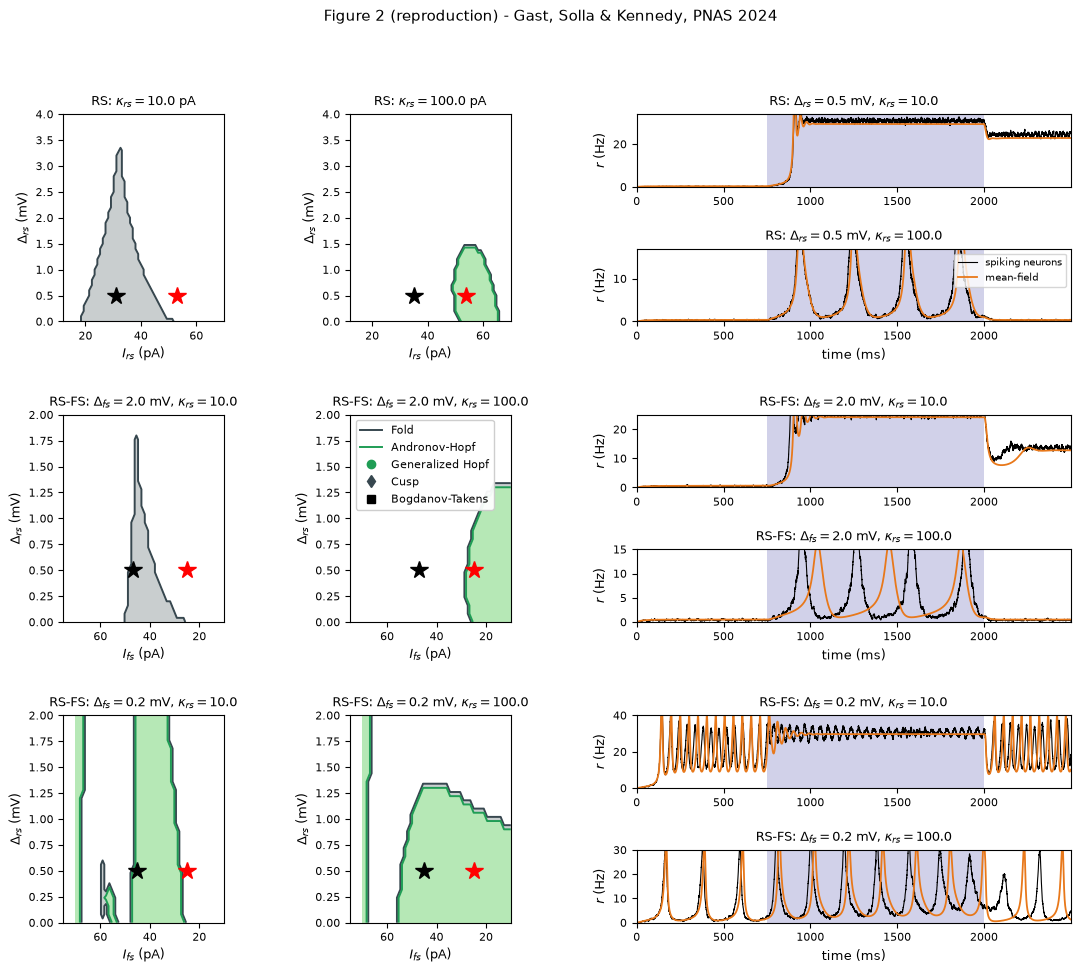

In [14]:
FIG_LETTERS = ["A-D", "E-H", "I-L"]
BLOCKS = [
    (Z_A, Z_B, r"$I_{rs}$ (pA)", False,
     [I_RS_SINGLE[10.0], I_RS_SINGLE[100.0]],
     [(dyn_single[10.0], mf_single[10.0][1], r"RS: $\Delta_{rs}=0.5$ mV, $\kappa_{rs}=10.0$", 34),
      (dyn_single[100.0], mf_single[100.0][1], r"RS: $\Delta_{rs}=0.5$ mV, $\kappa_{rs}=100.0$", 17)]),
    (Z_E, Z_F, r"$I_{fs}$ (pA)", True,
     [I_FS_TWO[(2.0, 10.0)], I_FS_TWO[(2.0, 100.0)]],
     [(dyn_two[(2.0, 10.0)], mf_two[(2.0, 10.0)][1], r"RS-FS: $\Delta_{fs}=2.0$ mV, $\kappa_{rs}=10.0$", 25),
      (dyn_two[(2.0, 100.0)], mf_two[(2.0, 100.0)][1], r"RS-FS: $\Delta_{fs}=2.0$ mV, $\kappa_{rs}=100.0$", 15)]),
    (Z_I, Z_J, r"$I_{fs}$ (pA)", True,
     [I_FS_TWO[(0.2, 10.0)], I_FS_TWO[(0.2, 100.0)]],
     [(dyn_two[(0.2, 10.0)], mf_two[(0.2, 10.0)][1], r"RS-FS: $\Delta_{fs}=0.2$ mV, $\kappa_{rs}=10.0$", 40),
      (dyn_two[(0.2, 100.0)], mf_two[(0.2, 100.0)][1], r"RS-FS: $\Delta_{fs}=0.2$ mV, $\kappa_{rs}=100.0$", 30)]),
]
BIF_TITLES = [
    (r"RS: $\kappa_{rs}=10.0$ pA", r"RS: $\kappa_{rs}=100.0$ pA"),
    (r"RS-FS: $\Delta_{fs}=2.0$ mV, $\kappa_{rs}=10.0$", r"RS-FS: $\Delta_{fs}=2.0$ mV, $\kappa_{rs}=100.0$"),
    (r"RS-FS: $\Delta_{fs}=0.2$ mV, $\kappa_{rs}=10.0$", r"RS-FS: $\Delta_{fs}=0.2$ mV, $\kappa_{rs}=100.0$"),
]


def draw_block(fig, gsblock, bi):
    """Draw one of the three row-blocks (2 stacked bifurcation panels + 2 dynamics panels)."""
    ZL, ZR, xlab, flip, stars_pair, dyns = BLOCKS[bi]
    sub = gsblock.subgridspec(2, 3, width_ratios=[1, 1, 2.7], hspace=0.85, wspace=0.5)
    Is, Ds = (Is_s, Ds_s) if bi == 0 else (Is_t, Ds_t)
    for col, (Z, ttl) in enumerate([(ZL, BIF_TITLES[bi][0]), (ZR, BIF_TITLES[bi][1])]):
        axb = fig.add_subplot(sub[:, col])
        plot_bifurcation(axb, Is, Ds, Z, ttl, xlab, flip, legend=(bi == 1 and col == 1))
        star(axb, stars_pair[col][0], 0.5, "black")
        star(axb, stars_pair[col][1], 0.5, "red")
    for row, (dyn, mf, ttl, ymax) in enumerate(dyns):
        axd = fig.add_subplot(sub[row, 2])
        plot_dynamics(axd, dyn[0], dyn[1], mf, ttl, ymax, xlabel=(row == 1))
        if bi == 0 and row == 1:
            axd.legend(fontsize=7, loc="upper right")


fig = plt.figure(figsize=(13, 10.5))
outer = fig.add_gridspec(3, 1, hspace=0.45, height_ratios=[1, 1, 1])
for bi in range(3):
    draw_block(fig, outer[bi], bi)
fig.suptitle("Figure 2 (reproduction) - Gast, Solla & Kennedy, PNAS 2024", fontsize=11)
fig.savefig("reproduce_figure_Gast_2024_PNAS.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Comparison with the original manuscript figure

The reference figure is the published Figure 2 of Gast, Solla & Kennedy (2024)
(open-access PNAS article; reproduced here with attribution for comparison only).
Each row below places the original manuscript panels (top) directly above our
reproduction (bottom).

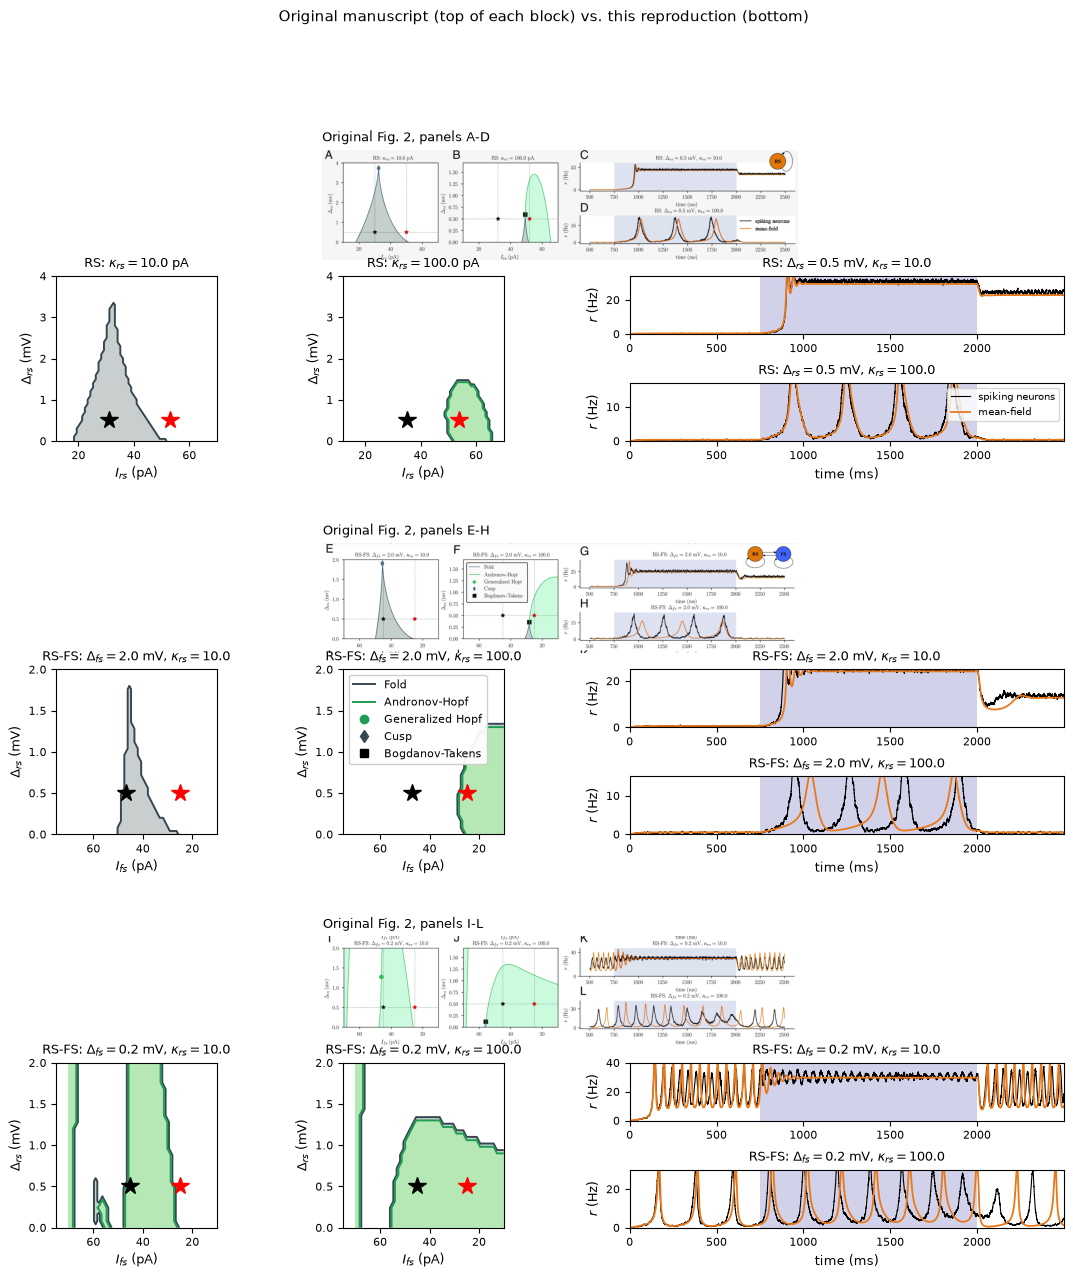

In [15]:
ORIGINAL = plt.imread("figures/Gast_2024_pnas_fig2.jpg")
# vertical extent of the three row-blocks within the published figure
orig_rows = [(8, 935), (935, 1865), (1865, 2795)]
orig_cols = (0, ORIGINAL.shape[1])

figc = plt.figure(figsize=(13, 14))
comp = figc.add_gridspec(3, 1, hspace=0.35, height_ratios=[1, 1, 1])
for bi in range(3):
    gg = comp[bi].subgridspec(2, 1, height_ratios=[1.0, 1.5], hspace=0.12)
    axo = figc.add_subplot(gg[0])
    y0, y1 = orig_rows[bi]
    axo.imshow(ORIGINAL[y0:y1, orig_cols[0]:orig_cols[1]], aspect="equal")
    axo.set_axis_off()
    axo.set_title(f"Original Fig. 2, panels {FIG_LETTERS[bi]}", fontsize=9, loc="left")
    draw_block(figc, gg[1], bi)
figc.suptitle("Original manuscript (top of each block) vs. this reproduction (bottom)",
              fontsize=11)
figc.savefig("reproduce_figure_Gast_2024_PNAS_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. What the reproduction shows

* **A, B (single RS population).** Weak adaptation ($\kappa_{rs}=10$ pA) gives a broad
  **bistable** (gray) regime bounded by two fold curves that meet in a cusp; strong
  adaptation ($\kappa_{rs}=100$ pA) shrinks the bistable region and opens a large
  **oscillatory** (green) regime bounded by an Andronov-Hopf loop.
* **C, D (dynamics).** With weak adaptation the network latches into persistent
  spiking after the input step and stays there (bistability / hysteresis); with
  strong adaptation it produces slow oscillatory bursts and returns to quiescence.
* **E, F (RS-FS, heterogeneous FS, $\Delta_{fs}=2$ mV).** The FS population *preserves*
  the bifurcation structure of the RS population: E resembles A, F resembles B
  (note the flipped $I_{fs}$ axis - higher $I_{fs}$ means more inhibition).
* **I, J (RS-FS, homogeneous FS, $\Delta_{fs}=0.2$ mV).** Homogeneous inhibition
  *overwrites* the RS structure and pushes the network into a large **oscillatory**
  regime.
* **G, H, K, L (dynamics).** With heterogeneous FS interneurons the RS population
  reproduces the single-population behaviour (G ~ C, H ~ D). With homogeneous FS
  interneurons the network oscillates throughout (K, L).

### References
* Gast, R., Solla, S. A., & Kennedy, A. (2024). *Neural heterogeneity controls
  computations in spiking neural networks.* PNAS 121(22), e2311885121.
* Gast, R., Schmidt, H., & Knösche, T. R. (2021). *A mean-field description of
  bursting, chattering and resonating dynamics in adaptive Izhikevich networks.*
  Frontiers in Computational Neuroscience.
* Izhikevich, E. M. (2003). *Simple model of spiking neurons.* IEEE TNN 14(6).
* Authors' reproduction scripts: Zenodo 10.5281/zenodo.10420635 (PyRates/RectiPy/PyCoBi).